## 1. Importing Necessary Libraries and Modules

In [8]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import time

from src.model.training.callbacks import get_callbacks
from src.model.training.data import compute_class_weights
import src.data.feature_extraction as fe
import src.data.augmentation as aug
from config.paths import RAW_VIDEO_DIR, PROCESSED_DATA_DIR, PLOTS_DIR

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from keras.layers import Masking, Conv1D, MaxPooling1D
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, LearningRateScheduler

np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.15.1


## 2. Data Loading and Preprocessing

In [10]:
WORDS = [item.name for item in RAW_VIDEO_DIR.iterdir()]
NUM_CLASSES = len(WORDS)

In [11]:
WORDS, NUM_CLASSES

(['hearing',
  'water',
  'no',
  'color',
  'bird',
  'now',
  'ball',
  'cousin',
  'mother',
  'forget',
  'yes',
  'wrong',
  'black',
  'candy',
  'orange'],
 15)

### 2.1 Loading Data (Sequences and Labels)

In [12]:
X_sequences = np.load(PROCESSED_DATA_DIR / "X_sequences.npy")
y_labels = np.load(PROCESSED_DATA_DIR / "y_labels.npy")

print(f"Loaded {len(X_sequences)} video sequences with each sequence shape {X_sequences.shape[1:]}")
print(f"Loaded {len(y_labels)} video labels")

Loaded 177 video sequences with each sequence shape (30, 42, 3)
Loaded 177 video labels


In [13]:
WORDS

['hearing',
 'water',
 'no',
 'color',
 'bird',
 'now',
 'ball',
 'cousin',
 'mother',
 'forget',
 'yes',
 'wrong',
 'black',
 'candy',
 'orange']

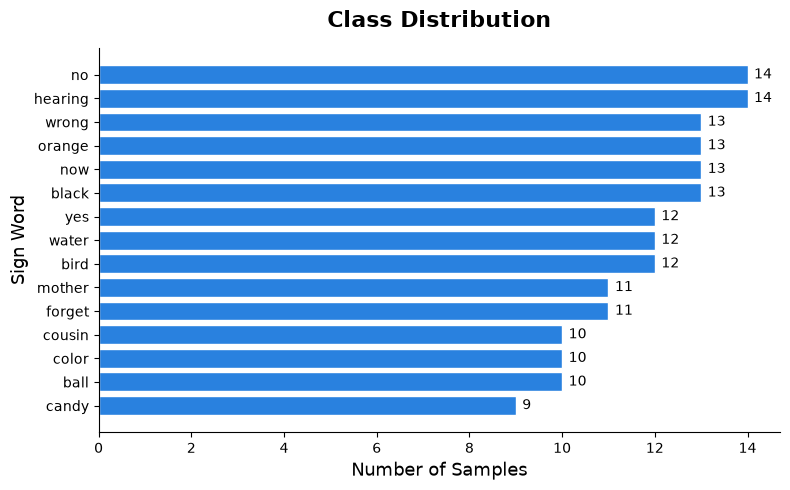

In [14]:
# plotting class distribution
unique, counts = np.unique(y_labels, return_counts=True)
sorted_idx = np.argsort(counts)[::-1]
unique = unique[sorted_idx]
counts = counts[sorted_idx]

plt.figure(figsize=(8, 5))
plt.title('Class Distribution', fontsize=16, fontweight='bold', pad=15)
bars = plt.barh(unique, counts, color="#2981DF", edgecolor="white")
plt.gca().invert_yaxis()
plt.xlabel("Number of Samples", fontsize=13)
plt.ylabel("Sign Word", fontsize=13)

for bar, count in zip(bars, counts):
    plt.text(
        bar.get_width() + max(counts) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=10
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution.png", dpi=300)
plt.show()

### 2.2 Data Augmentation

In [15]:
y_labels

array(['hearing', 'hearing', 'hearing', 'hearing', 'hearing', 'hearing',
       'hearing', 'hearing', 'hearing', 'hearing', 'hearing', 'hearing',
       'hearing', 'hearing', 'water', 'water', 'water', 'water', 'water',
       'water', 'water', 'water', 'water', 'water', 'water', 'water',
       'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no', 'no',
       'no', 'no', 'no', 'color', 'color', 'color', 'color', 'color',
       'color', 'color', 'color', 'color', 'color', 'bird', 'bird',
       'bird', 'bird', 'bird', 'bird', 'bird', 'bird', 'bird', 'bird',
       'bird', 'bird', 'now', 'now', 'now', 'now', 'now', 'now', 'now',
       'now', 'now', 'now', 'now', 'now', 'now', 'ball', 'ball', 'ball',
       'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'ball', 'cousin',
       'cousin', 'cousin', 'cousin', 'cousin', 'cousin', 'cousin',
       'cousin', 'cousin', 'cousin', 'mother', 'mother', 'mother',
       'mother', 'mother', 'mother', 'mother', 'mother', 'mother',
       'm

In [16]:
# Split raw sequences BEFORE augmentation
X_train, X_test, y_train, y_test = train_test_split(X_sequences, y_labels, test_size=0.2, stratify=y_labels, random_state=42) 
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

# Apply augmentation ONLY to the training set
X_train_aug, y_train_aug = aug.generate_augmented_dataset(X_train, y_train)

print(f"Original train dataset size: {len(X_train)}")
print(f"Augmented train dataset size: {len(X_train_aug)}")
# No augmentation for test set
X_test_aug, y_test_aug = X_test, y_test
# X_test_aug, y_test_aug = generate_augmented_dataset(X_test_raw, y_test)

unique_aug, counts_aug = np.unique(y_train_aug, return_counts=True)

(141, 30, 42, 3) (36, 30, 42, 3) (141,) (36,)
Generating Augmented data.....
Original train dataset size: 141
Augmented train dataset size: 564


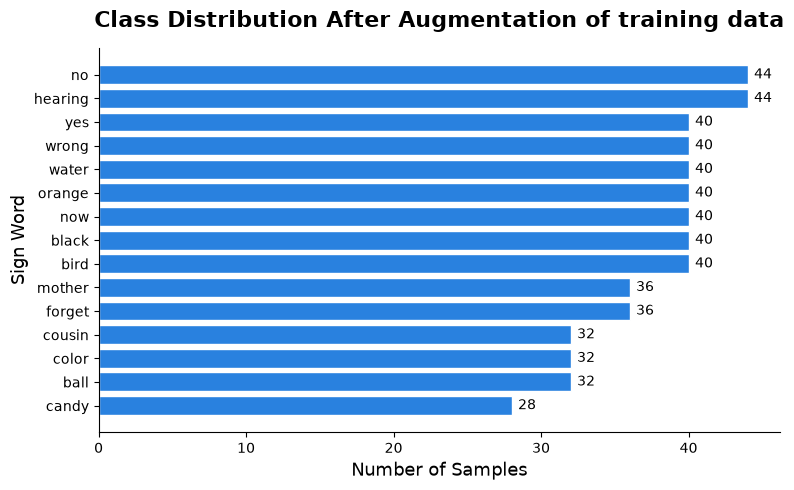

In [17]:
#plotting class distribution after augmentation
sorted_idx = np.argsort(counts_aug)[::-1]
unique_aug = unique_aug[sorted_idx]
counts_aug = counts_aug[sorted_idx]

plt.figure(figsize=(8, 5))
plt.title('Class Distribution After Augmentation of training data', fontsize=16, fontweight='bold', pad=15)
bars = plt.barh(unique_aug, counts_aug, color="#2981DF", edgecolor="white")
plt.gca().invert_yaxis()
plt.xlabel("Number of Samples", fontsize=13)
plt.ylabel("Sign Word", fontsize=13)

for bar, count in zip(bars, counts_aug):
    plt.text(
        bar.get_width() + max(counts_aug) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,}",
        va="center",
        fontsize=10
    )

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "class_distribution_after_augmentation.png", dpi=300)
plt.show()

### 2.3 Extracting Features

In [18]:
print("Extracting Train Data Features")
X_train_features = np.array([fe.extract_features_3d(seq) for seq in X_train_aug])
print(X_train_features.shape)  # (num_train_samples, num_features)

print("Extracting Test Data Features")
X_test_features = np.array([fe.extract_features_3d(seq) for seq in X_test_aug])
print(X_test_features.shape)   # (num_test_samples, num_features)

Extracting Train Data Features
(564, 1134)
Extracting Test Data Features
(36, 1134)


### 2.4 Scaling Data 

In [19]:
# Scaling data for classic ml models (required)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)
X_train_scaled.shape

(564, 1134)

## 3. Modelling

In [20]:
training_time = {}

### 3.1 Classical Machine Learning Models

In [21]:
print('Training Logistic Regression.......')
lr_model = LogisticRegression(max_iter=2000)
training_start = time.perf_counter()
lr_model.fit(X_train_scaled, y_train_aug)
training_time["Logistic Regression"] = time.perf_counter()-training_start

print('\nTraining SVM.......')
training_start = time.perf_counter()
svm_model = SVC(kernel='rbf', probability=True)
svm_model.fit(X_train_scaled, y_train_aug)
training_time["SVM"] = time.perf_counter()-training_start

print('\nTraining Random Forest.......')
training_start = time.perf_counter()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train_aug)
training_time["Random Forest"] = time.perf_counter()-training_start

print("\nAll machine learning models trained.")

Training Logistic Regression.......

Training SVM.......


/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



Training Random Forest.......

All machine learning models trained.


#### Model Evaluation

In [22]:
def evaluate(model, model_name):
    y_pred = model.predict(X_test_scaled)
    print(f"\n{model_name} Classification Report:\n")
    print(classification_report(y_test_aug, y_pred))
    cm = confusion_matrix(y_test_aug, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=WORDS, yticklabels=WORDS)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.savefig(PLOTS_DIR / f"confusion_matrix_{model_name}.png", dpi=300)
    plt.show()
    return classification_report(y_test, y_pred, output_dict=True)


Logistic Regression Classification Report:

              precision    recall  f1-score   support

        ball       0.67      1.00      0.80         2
        bird       0.50      0.50      0.50         2
       black       1.00      0.33      0.50         3
       candy       0.50      0.50      0.50         2
       color       0.67      1.00      0.80         2
      cousin       1.00      0.50      0.67         2
      forget       0.67      1.00      0.80         2
     hearing       1.00      0.67      0.80         3
      mother       0.33      0.50      0.40         2
          no       0.33      0.33      0.33         3
         now       1.00      0.67      0.80         3
      orange       1.00      0.33      0.50         3
       water       0.00      0.00      0.00         2
       wrong       0.75      1.00      0.86         3
         yes       0.50      1.00      0.67         2

    accuracy                           0.61        36
   macro avg       0.66      0.62  

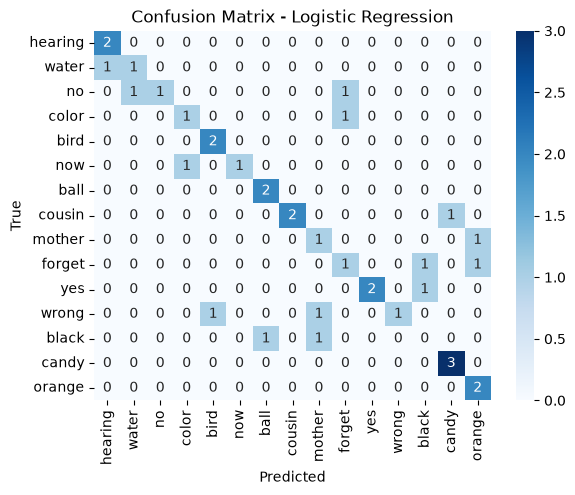

In [23]:
lr_report = evaluate(lr_model, "Logistic Regression")


SVM Classification Report:

              precision    recall  f1-score   support

        ball       0.50      1.00      0.67         2
        bird       0.00      0.00      0.00         2
       black       0.00      0.00      0.00         3
       candy       0.00      0.00      0.00         2
       color       1.00      0.50      0.67         2
      cousin       0.00      0.00      0.00         2
      forget       0.33      0.50      0.40         2
     hearing       0.50      0.33      0.40         3
      mother       0.50      0.50      0.50         2
          no       1.00      0.33      0.50         3
         now       1.00      0.67      0.80         3
      orange       0.00      0.00      0.00         3
       water       0.00      0.00      0.00         2
       wrong       0.33      0.33      0.33         3
         yes       0.50      0.50      0.50         2

    accuracy                           0.31        36
   macro avg       0.38      0.31      0.32        

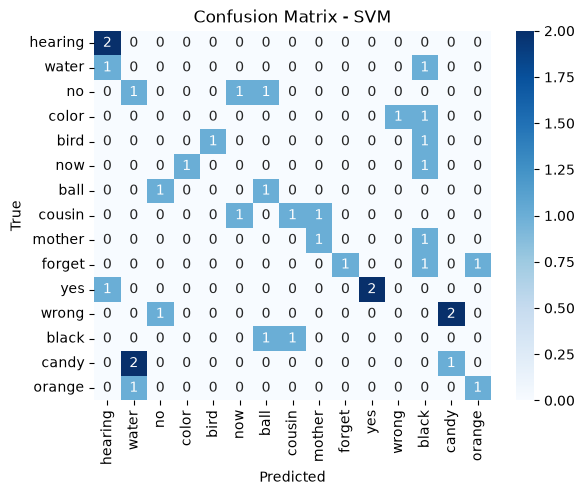

In [24]:
svm_report = evaluate(svm_model, "SVM")


Random Forest Classification Report:

              precision    recall  f1-score   support

        ball       0.67      1.00      0.80         2
        bird       0.33      0.50      0.40         2
       black       0.00      0.00      0.00         3
       candy       0.50      0.50      0.50         2
       color       0.00      0.00      0.00         2
      cousin       0.00      0.00      0.00         2
      forget       0.33      0.50      0.40         2
     hearing       0.40      0.67      0.50         3
      mother       0.00      0.00      0.00         2
          no       0.50      0.67      0.57         3
         now       1.00      1.00      1.00         3
      orange       0.00      0.00      0.00         3
       water       0.00      0.00      0.00         2
       wrong       0.50      0.67      0.57         3
         yes       0.40      1.00      0.57         2

    accuracy                           0.44        36
   macro avg       0.31      0.43      0.

/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

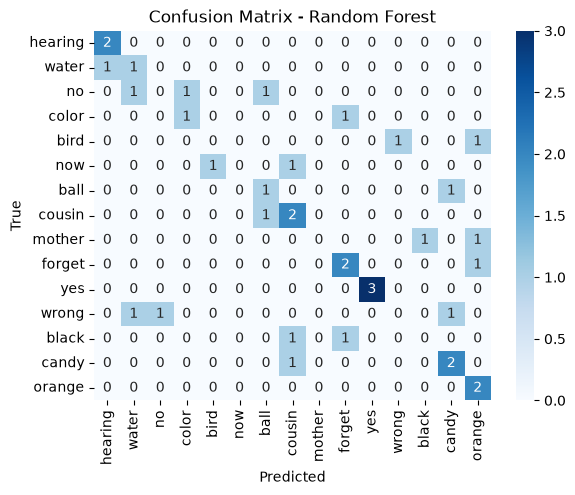

/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

In [25]:
rf_report = evaluate(rf_model, "Random Forest")

In [26]:
def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title(f'{model_name} Training and Validation Accuracy')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title(f'{model_name} Training and Validation Loss')
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{model_name}_training_history.png', dpi=300)
    plt.show()

### 3.2 Neural Network

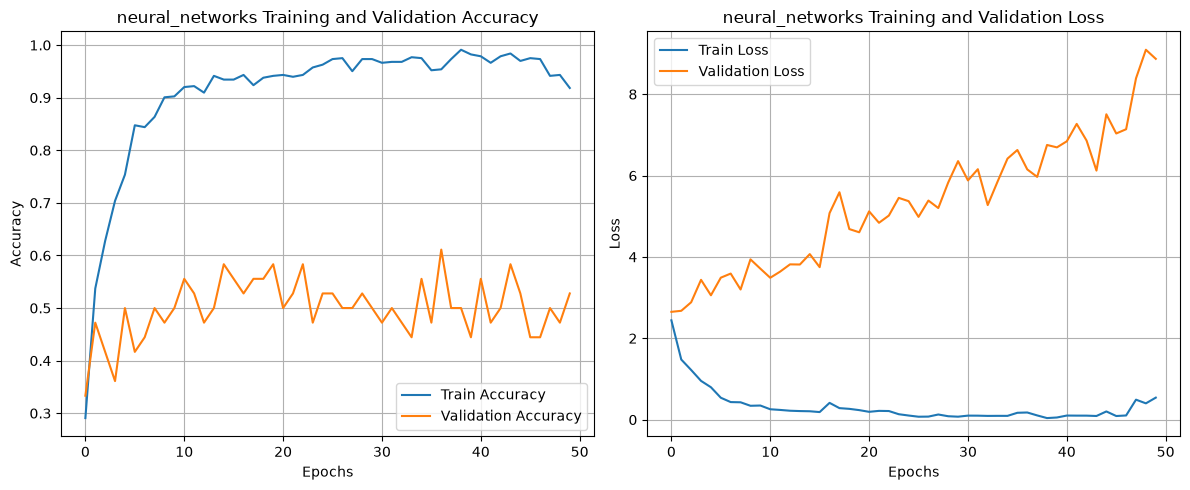

In [27]:
class_weights = compute_class_weights(y_train_aug)  # t handle class imbalance
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax')
])
le = LabelEncoder()
y_train_aug_encoded = le.fit_transform(y_train_aug)
y_test_aug_encoded = le.transform(y_test_aug)
nn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
training_start = time.perf_counter()
history_nn = nn_model.fit(X_train_scaled, y_train_aug_encoded, validation_data=(X_test_scaled, y_test_aug_encoded), epochs=50, batch_size=8, verbose=0)
training_time["Neural Network"] = time.perf_counter() - training_start

# Plot training history
plot_history(history_nn, 'neural_networks')

#### Model Evaluation

2/2 [==============================] - 0s 914us/step

Neural Network Classification Report:

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         2
           1       0.33      0.50      0.40         2
           2       0.00      0.00      0.00         3
           3       0.33      0.50      0.40         2
           4       0.67      1.00      0.80         2
           5       0.00      0.00      0.00         2
           6       1.00      1.00      1.00         2
           7       1.00      0.67      0.80         3
           8       0.00      0.00      0.00         2
           9       0.67      0.67      0.67         3
          10       1.00      0.67      0.80         3
          11       0.00      0.00      0.00         3
          12       0.00      0.00      0.00         2
          13       0.60      1.00      0.75         3
          14       0.67      1.00      0.80         2

    accuracy                           0.

/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with 

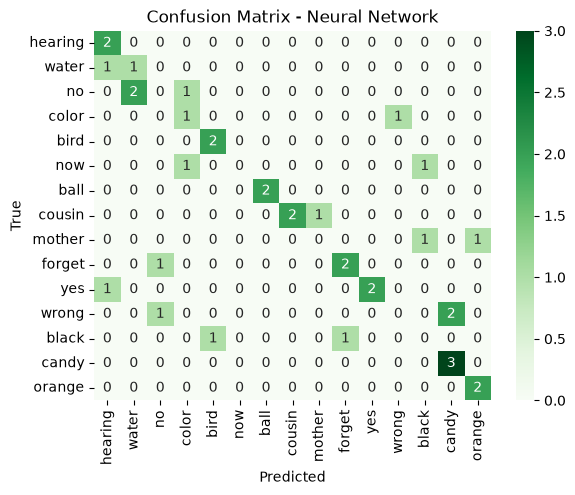

In [28]:
nn_preds = np.argmax(nn_model.predict(X_test_scaled), axis=1)
print("\nNeural Network Classification Report:\n")
print(classification_report(y_test_aug_encoded, nn_preds))
nn_report = classification_report(y_test_aug_encoded, nn_preds, output_dict=True)
cm_nn = confusion_matrix(y_test_aug_encoded, nn_preds)
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Greens', xticklabels=WORDS, yticklabels=WORDS)
plt.title("Confusion Matrix - Neural Network")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(PLOTS_DIR / f"neural_network_confusion_matrix.png", dpi=300)
plt.show()

***Observations:***
- Model is overfitting with the training accuracy staying above 90% and validation accuracy below 50%
- many classes performed poorly

### 3.3 LSTM

#### Data Preparation

In [29]:
X_lstm = X_sequences.reshape((X_sequences.shape[0], X_sequences.shape[1], -1))  # (147, 30, 126)

num_classes = len(WORDS)

In [30]:
X_normalized = np.zeros_like(X_lstm)
for i in range(X_lstm.shape[0]):
    X_normalized[i] = (X_lstm[i] - np.mean(X_lstm[i])) / (np.std(X_lstm[i]) + 1e-8)

y_lstm=y_labels

In [31]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_lstm)

In [32]:
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(X_normalized, y_encoded, test_size=0.2, random_state=42)

X_train_lstm_aug, y_train_lstm_aug = aug.augment_sequential_data(X_train_lstm, y_train_lstm)

print(f"LSTM data shapes:")
print(f"Training: {X_train_lstm_aug.shape}, {y_train_lstm_aug.shape}")
print(f"Testing: {X_test_lstm.shape}, {y_test_lstm.shape}")

Augmenting LSTM-compatible data...
LSTM data shapes:
Training: (564, 30, 126), (564,)
Testing: (36, 30, 126), (36,)


#### Model Architecture

In [33]:
def intialize_lstm_model(optimizer):
    model = Sequential([
        # Masking layer for any padded sequences
        Masking(mask_value=0., input_shape=(30, 126)),
        
        # First bidirectional LSTM layer
        Bidirectional(LSTM(256, return_sequences=True, recurrent_dropout=0.2)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Second bidirectional LSTM layer
        Bidirectional(LSTM(128, return_sequences=True)),
        BatchNormalization(),
        Dropout(0.3),
        
        # Third bidirectional LSTM layer
        Bidirectional(LSTM(64)),
        BatchNormalization(),
        
        # Fully connected layers
        Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.3),
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

lstm_class_weights = compute_class_weights(y_train_lstm_aug)
callbacks = get_callbacks()

In [34]:
print('Trainig lstm without augmented data')
lstm_model = intialize_lstm_model(Adam(learning_rate=0.0005))
history_lstm = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    class_weight=lstm_class_weights,
    verbose=1
)

Trainig lstm without augmented data
Epoch 1/100
9/9 [==============================] - 7s 252ms/step - loss: 3.4321 - accuracy: 0.0426 - val_loss: 2.8794 - val_accuracy: 0.1111 - lr: 2.0000e-04
Epoch 2/100
9/9 [==============================] - 1s 106ms/step - loss: 2.9751 - accuracy: 0.1773 - val_loss: 2.8341 - val_accuracy: 0.2500 - lr: 4.0000e-04
Epoch 3/100
9/9 [==============================] - 1s 107ms/step - loss: 2.7308 - accuracy: 0.1986 - val_loss: 2.8216 - val_accuracy: 0.1667 - lr: 6.0000e-04
Epoch 4/100
9/9 [==============================] - 1s 107ms/step - loss: 2.6565 - accuracy: 0.1844 - val_loss: 2.7945 - val_accuracy: 0.1944 - lr: 8.0000e-04
Epoch 5/100
9/9 [==============================] - 1s 110ms/step - loss: 2.4995 - accuracy: 0.2766 - val_loss: 2.7720 - val_accuracy: 0.1111 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 1s 108ms/step - loss: 2.3695 - accuracy: 0.3333 - val_loss: 2.6458 - val_accuracy: 0.2778 - lr: 0.0010
Epoch 7/100
9/9 [=======

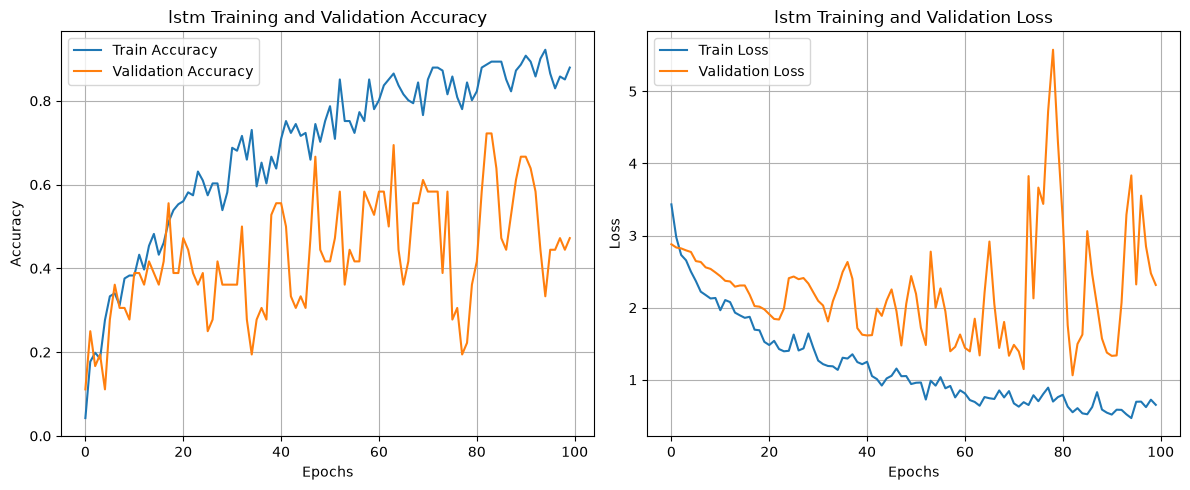

In [35]:
# Plot LSTM training history
plot_history(history_lstm, 'lstm')

In [36]:
print('Trainig LSTM with augmented data')
lstm_model = intialize_lstm_model(Adam(learning_rate=0.0005))
training_start = time.perf_counter()
history_lstm_aug = lstm_model.fit(
    X_train_lstm_aug, y_train_lstm_aug,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=16,
    callbacks=callbacks,
    class_weight=lstm_class_weights,
    verbose=1
)
training_time["LSTM"] = time.perf_counter()-training_start

Trainig LSTM with augmented data
Epoch 1/100
36/36 [==============================] - 10s 133ms/step - loss: 3.0264 - accuracy: 0.1454 - val_loss: 2.7827 - val_accuracy: 0.2500 - lr: 2.0000e-04
Epoch 2/100
36/36 [==============================] - 4s 102ms/step - loss: 2.6002 - accuracy: 0.2465 - val_loss: 2.6659 - val_accuracy: 0.3056 - lr: 4.0000e-04
Epoch 3/100
36/36 [==============================] - 4s 116ms/step - loss: 2.4111 - accuracy: 0.2606 - val_loss: 2.5510 - val_accuracy: 0.3333 - lr: 6.0000e-04
Epoch 4/100
36/36 [==============================] - 5s 136ms/step - loss: 2.2025 - accuracy: 0.3191 - val_loss: 2.2734 - val_accuracy: 0.3611 - lr: 8.0000e-04
Epoch 5/100
36/36 [==============================] - 5s 136ms/step - loss: 1.9350 - accuracy: 0.4379 - val_loss: 2.0357 - val_accuracy: 0.4167 - lr: 0.0010
Epoch 6/100
36/36 [==============================] - 5s 137ms/step - loss: 1.8474 - accuracy: 0.4433 - val_loss: 2.3692 - val_accuracy: 0.2778 - lr: 0.0010
Epoch 7/100
36

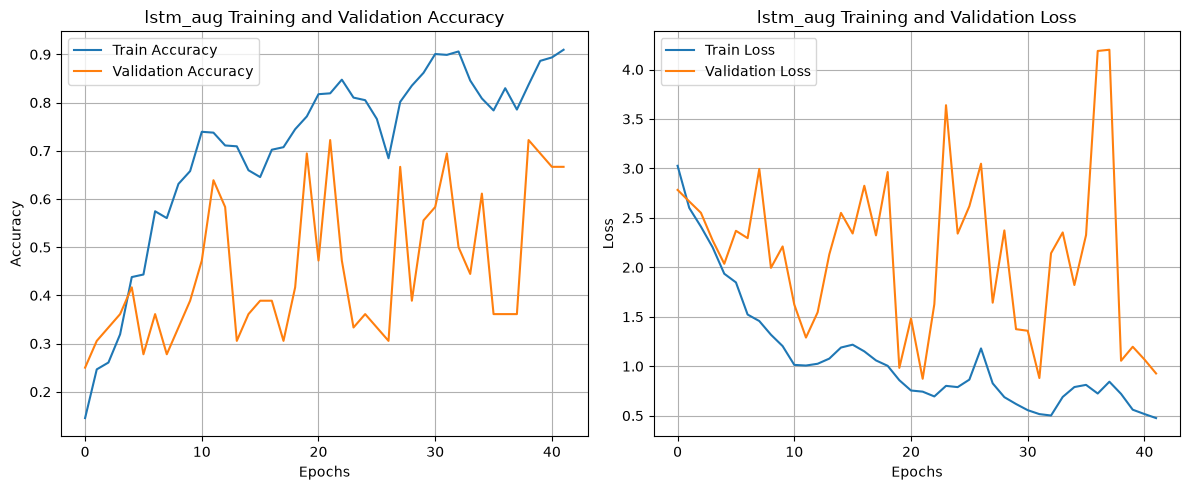

In [37]:
# Plot LSTM training history
plot_history(history_lstm_aug, 'lstm_aug')
# lstm_model.save(MODELS_DIR / "lstm_model.keras")

#### Model Comparison LSTM with and without augmented data

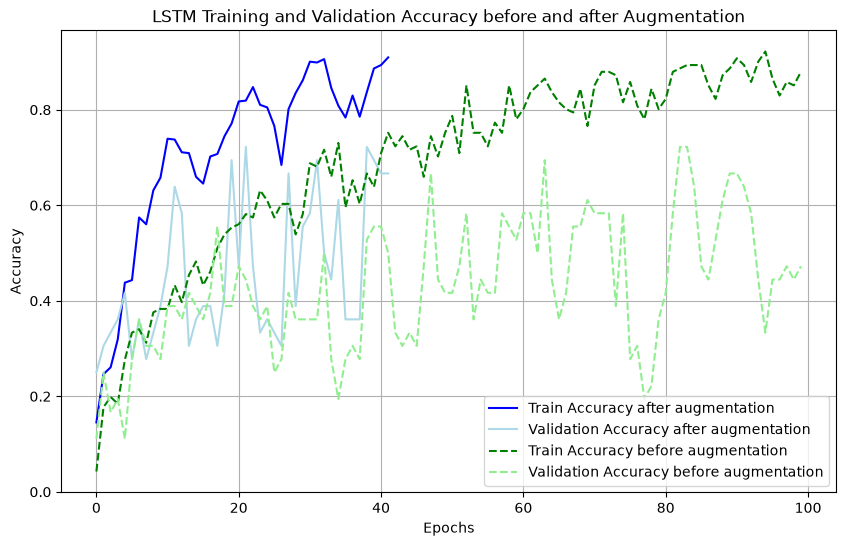

In [38]:
plt.figure(figsize=(10,6))
plt.plot(history_lstm_aug.history['accuracy'], label='Train Accuracy after augmentation', color='blue')
plt.plot(history_lstm_aug.history['val_accuracy'], label='Validation Accuracy after augmentation', color='lightblue')
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy before augmentation',color='green',linestyle='dashed')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy before augmentation', color='lightgreen', linestyle='dashed')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'LSTM Training and Validation Accuracy before and after Augmentation')
plt.grid(True)
plt.savefig(PLOTS_DIR / "lstm_training_curves_with_tithout_augmentation.png", dpi=300)
plt.show()

#### Mdel Evaluation

In [39]:
y_pred = lstm_model.predict(X_test_lstm)
y_pred_classes = np.argmax(y_pred, axis=1)

# Classification report
print("\nLSTM Classification Report:")
print(classification_report(y_test_lstm, y_pred_classes))
lstm_report = classification_report(y_test_lstm, y_pred_classes, output_dict=True)

2/2 [==============================] - 1s 11ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       0.50      0.50      0.50         2
           2       0.33      0.50      0.40         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         1
           6       1.00      0.25      0.40         4
           7       0.67      1.00      0.80         2
           8       0.00      0.00      0.00         0
           9       0.00      0.00      0.00         3
          10       1.00      1.00      1.00         3
          11       0.67      0.67      0.67         3
          12       1.00      0.80      0.89         5
          13       0.67      1.00      0.80         2
          14       0.57      1.00      0.73         4

    accuracy                           0.72        36

/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/jayant/Documents/projects/real-time-sign-language-recognition/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predi

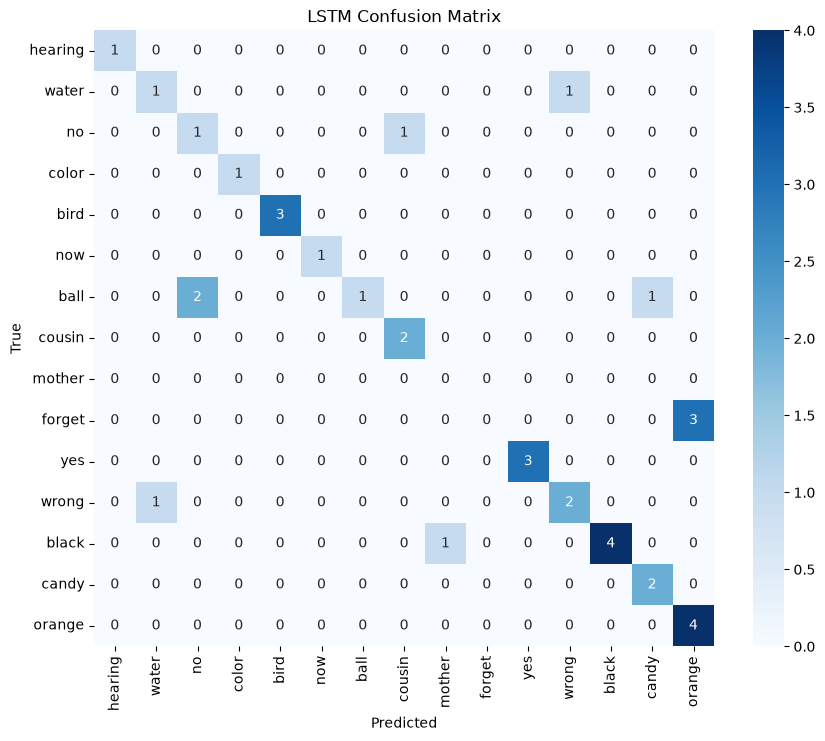

In [40]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test_lstm, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=WORDS, yticklabels=WORDS)
plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(PLOTS_DIR / "lstm_confusion_matrix.png", dpi=300)
plt.show()

### 3.4 CNN-LSTM Hybrid Model

In [41]:
early_stopping = EarlyStopping(
    monitor='val_loss', 
    patience=20, 
    restore_best_weights=True,
    verbose=1
)
def cosine_decay_with_warmup(epoch, total_epochs=100, warmup_epochs=5):
    if epoch < warmup_epochs:
        # Linear warmup
        return (epoch + 1) / warmup_epochs * 0.001
    else:
        # Cosine decay
        progress = (epoch - warmup_epochs) / (total_epochs - warmup_epochs)
        return 0.0001 + 0.0009 * 0.5 * (1 + np.cos(np.pi * progress))
    
lr_scheduler = LearningRateScheduler(cosine_decay_with_warmup)

# Also keep ReduceLROnPlateau as backup
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

#### Model Architecture

In [42]:
def intialize_cnn_lstm_model(optimizer):
    model = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(30, 126)),
        MaxPooling1D(pool_size=2),
        BatchNormalization(),
        
        Conv1D(filters=128, kernel_size=3, activation='relu'),
        MaxPooling1D(pool_size=2),
        BatchNormalization(),
        
        Bidirectional(LSTM(64)),
        BatchNormalization(),
        
        Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(loss='sparse_categorical_crossentropy', optimizer=optimizer, metrics=['accuracy'])
    return model

In [43]:
print('Trainig cnn-lstm without augmented data')
# Train CNN-LSTM model
cnn_lstm_model = intialize_cnn_lstm_model(Adam(learning_rate=0.0005))
history_cnn_lstm = cnn_lstm_model.fit(
    X_train_lstm, y_train_lstm,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    class_weight=lstm_class_weights,
    verbose=1
)

Trainig cnn-lstm without augmented data
Epoch 1/100
9/9 [==============================] - 1s 36ms/step - loss: 3.6699 - accuracy: 0.0638 - val_loss: 2.8419 - val_accuracy: 0.0278 - lr: 5.0000e-04
Epoch 2/100
9/9 [==============================] - 0s 5ms/step - loss: 2.9021 - accuracy: 0.1702 - val_loss: 2.8218 - val_accuracy: 0.0556 - lr: 5.0000e-04
Epoch 3/100
9/9 [==============================] - 0s 4ms/step - loss: 2.7087 - accuracy: 0.1631 - val_loss: 2.8074 - val_accuracy: 0.0556 - lr: 5.0000e-04
Epoch 4/100
9/9 [==============================] - 0s 4ms/step - loss: 2.2424 - accuracy: 0.2837 - val_loss: 2.7831 - val_accuracy: 0.0556 - lr: 5.0000e-04
Epoch 5/100
9/9 [==============================] - 0s 5ms/step - loss: 2.0322 - accuracy: 0.3617 - val_loss: 2.7564 - val_accuracy: 0.0278 - lr: 5.0000e-04
Epoch 6/100
9/9 [==============================] - 0s 5ms/step - loss: 1.8199 - accuracy: 0.3972 - val_loss: 2.7359 - val_accuracy: 0.0278 - lr: 5.0000e-04
Epoch 7/100
9/9 [======

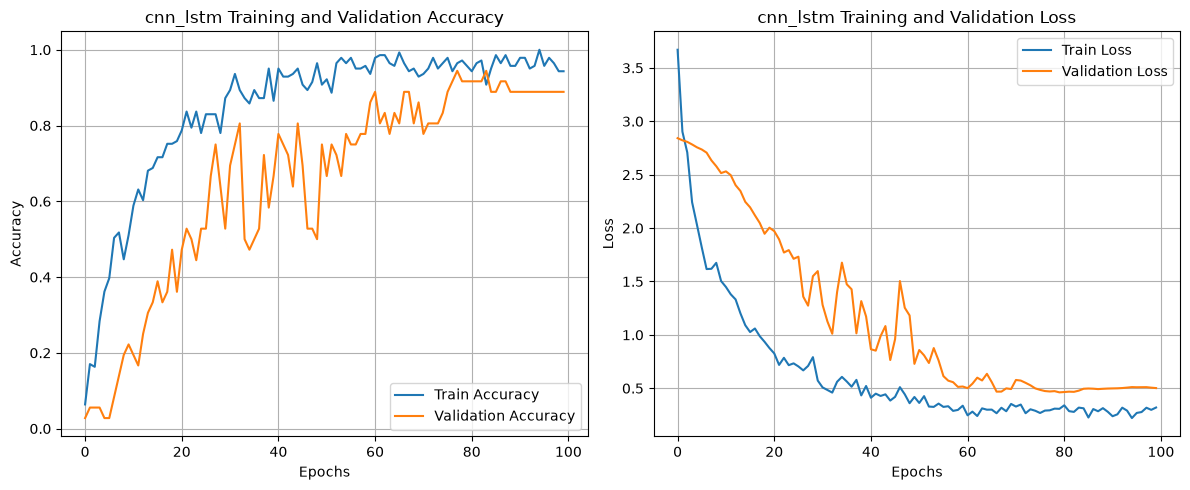

In [44]:
# Plot CNN-LSTM training history
plot_history(history_cnn_lstm, 'cnn_lstm')

In [45]:
print('Trainig CNN-LSTM with augmented data')
# Train CNN-LSTM model
cnn_lstm_model = intialize_cnn_lstm_model(Adam(learning_rate=0.0005))
training_start = time.perf_counter()
history_cnn_lstm_aug = cnn_lstm_model.fit(
    X_train_lstm_aug, y_train_lstm_aug,
    validation_data=(X_test_lstm, y_test_lstm),
    epochs=100,
    batch_size=16,
    callbacks=[early_stopping, reduce_lr],
    class_weight=lstm_class_weights,
    verbose=1
)
training_time["CNN-LSTM"] = time.perf_counter()-training_start

Trainig CNN-LSTM with augmented data
Epoch 1/100
36/36 [==============================] - 2s 11ms/step - loss: 2.7363 - accuracy: 0.2021 - val_loss: 2.6634 - val_accuracy: 0.1389 - lr: 5.0000e-04
Epoch 2/100
36/36 [==============================] - 0s 4ms/step - loss: 1.9454 - accuracy: 0.4149 - val_loss: 2.5948 - val_accuracy: 0.1944 - lr: 5.0000e-04
Epoch 3/100
36/36 [==============================] - 0s 3ms/step - loss: 1.5717 - accuracy: 0.5443 - val_loss: 2.4080 - val_accuracy: 0.2222 - lr: 5.0000e-04
Epoch 4/100
36/36 [==============================] - 0s 3ms/step - loss: 1.3495 - accuracy: 0.6046 - val_loss: 2.0641 - val_accuracy: 0.4444 - lr: 5.0000e-04
Epoch 5/100
36/36 [==============================] - 0s 3ms/step - loss: 1.1464 - accuracy: 0.6525 - val_loss: 1.8052 - val_accuracy: 0.5278 - lr: 5.0000e-04
Epoch 6/100
36/36 [==============================] - 0s 4ms/step - loss: 0.8909 - accuracy: 0.7571 - val_loss: 1.6571 - val_accuracy: 0.4722 - lr: 5.0000e-04
Epoch 7/100
36

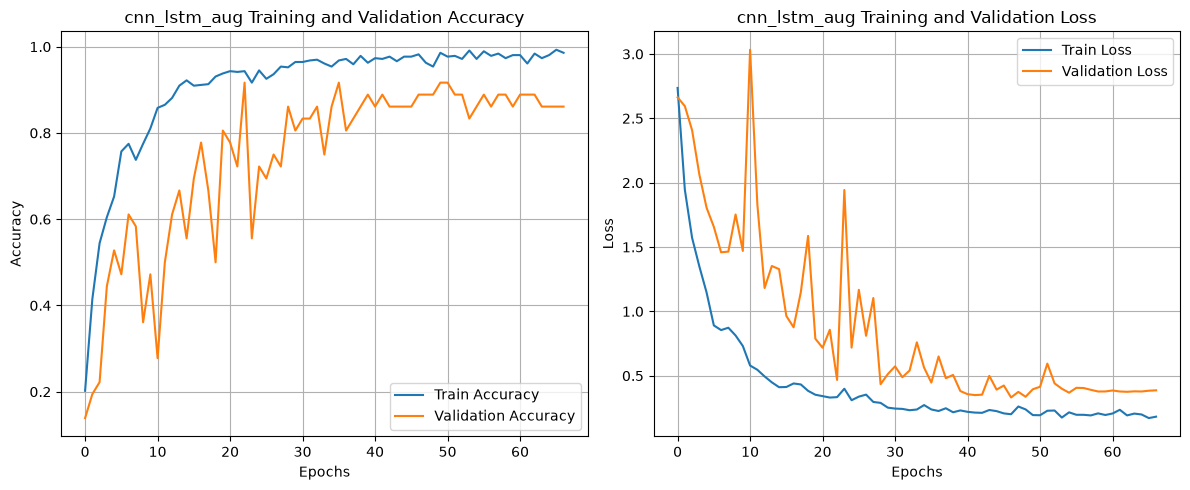

In [46]:
# Plot CNN-LSTM training history
plot_history(history_cnn_lstm_aug, 'cnn_lstm_aug')
# cnn_lstm_model.save(MODELS_DIR / "cnn_lstm_model.keras")

#### Model Comparison CNN-LSTM with and without augmented data

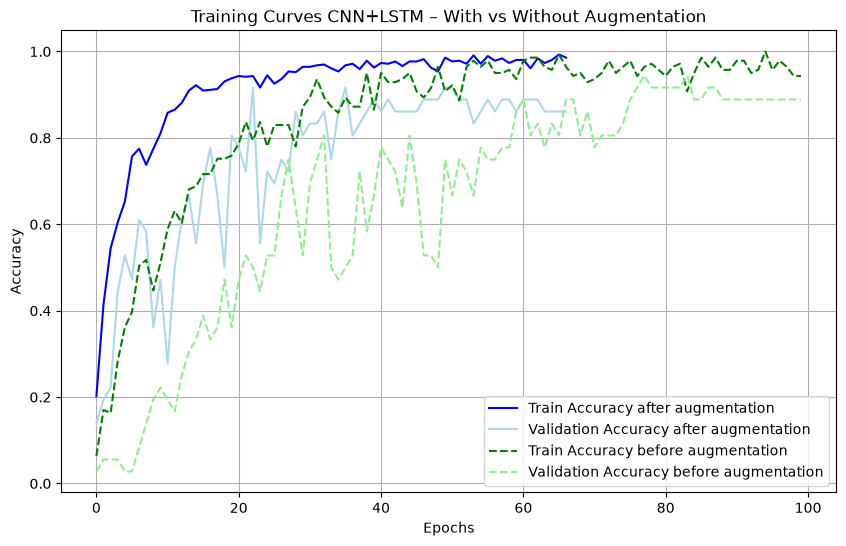

In [47]:
plt.figure(figsize=(10,6))
plt.plot(history_cnn_lstm_aug.history['accuracy'], label='Train Accuracy after augmentation', color='blue')
plt.plot(history_cnn_lstm_aug.history['val_accuracy'], label='Validation Accuracy after augmentation', color='lightblue')
plt.plot(history_cnn_lstm.history['accuracy'], label='Train Accuracy before augmentation',color='green',linestyle='dashed')
plt.plot(history_cnn_lstm.history['val_accuracy'], label='Validation Accuracy before augmentation', color='lightgreen', linestyle='dashed')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title(f'Training Curves CNN+LSTM – With vs Without Augmentation')
plt.grid(True)
plt.savefig(PLOTS_DIR / "cnn_lstm_training_curves_with_tithout_augmentation.png", dpi=300)
plt.show()

#### Model Evaluation

In [48]:
y_cnn_lstm_pred = cnn_lstm_model.predict(X_test_lstm)
y_cnn_lstm_classes = np.argmax(y_cnn_lstm_pred, axis=1)
print("\nCNN-LSTM Classification Report:")
print(classification_report(y_test_lstm, y_cnn_lstm_classes))
cnn_lstm_report = classification_report(y_test_lstm, y_cnn_lstm_classes,output_dict=True)

2/2 [==============================] - 0s 2ms/step

CNN-LSTM Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2
           2       0.67      1.00      0.80         2
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         3
           5       0.50      1.00      0.67         1
           6       1.00      0.50      0.67         4
           7       1.00      1.00      1.00         2
           9       0.75      1.00      0.86         3
          10       1.00      1.00      1.00         3
          11       1.00      0.67      0.80         3
          12       1.00      1.00      1.00         5
          13       0.67      1.00      0.80         2
          14       1.00      0.75      0.86         4

    accuracy                           0.89        36
   macro avg       0.90      0.92      0.89       

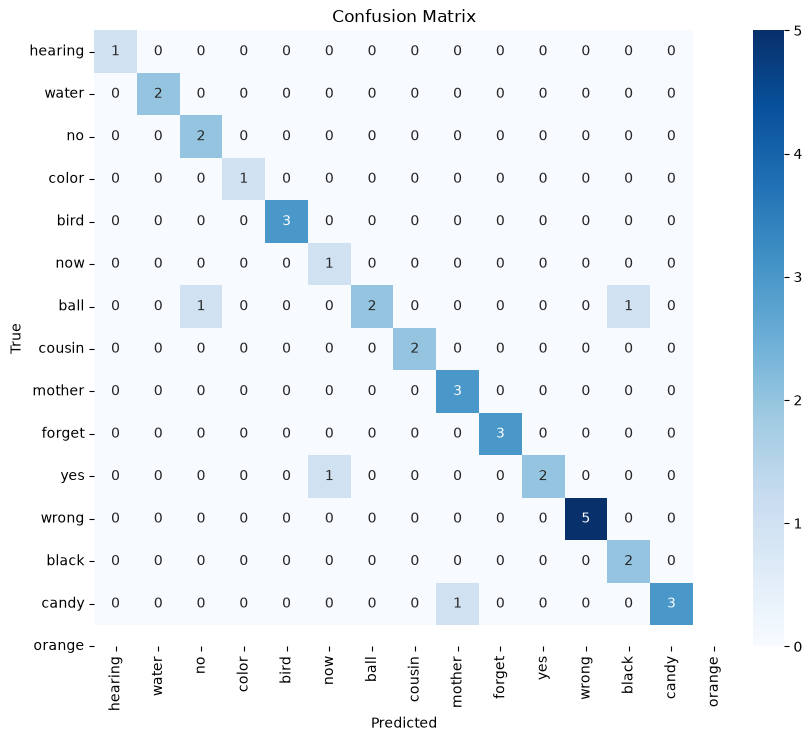

In [49]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test_lstm, y_cnn_lstm_classes)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=WORDS, yticklabels=WORDS)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(PLOTS_DIR / "cnn_lstm_confusion_matrix.png", dpi=300)
plt.show()

## 4. Final Model Comparison

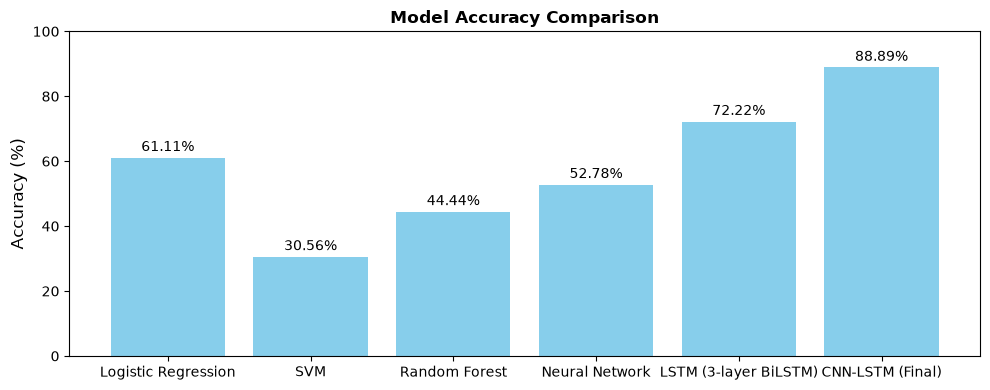

In [50]:
models = [
    "Logistic Regression",
    "SVM",
    "Random Forest",
    "Neural Network",
    "LSTM (3-layer BiLSTM)",
    "CNN-LSTM (Final)"
]

model_reports = [lr_report, svm_report, rf_report, nn_report, lstm_report, cnn_lstm_report]
accuracies = [round(report["accuracy"]*100,2) for report in model_reports]

plt.figure(figsize=(10, 4))
bars = plt.bar(models, accuracies, color='skyblue')
plt.title("Model Accuracy Comparison", fontweight="bold")
plt.ylabel("Accuracy (%)", fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 1, f'{height}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_accuracies_comparison.png", dpi=300)
plt.show()

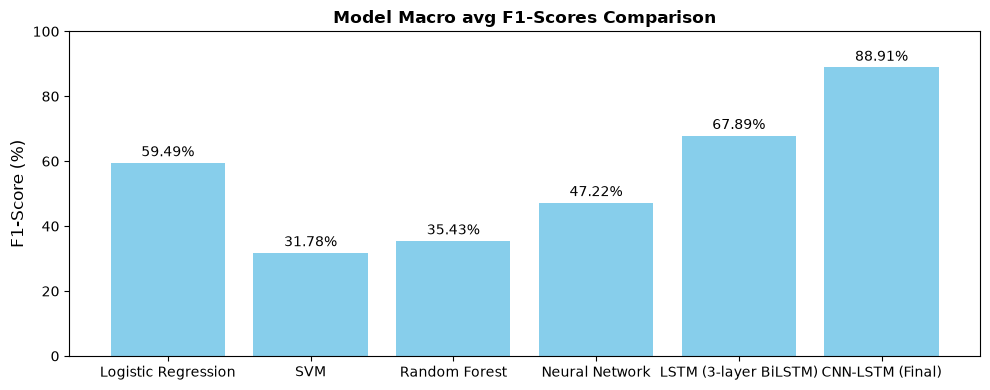

In [51]:
f1_scores = [round(report["macro avg"]["f1-score"]*100,2) for report in model_reports]

plt.figure(figsize=(10, 4))
bars = plt.bar(models, f1_scores, color='skyblue')
plt.title("Model Macro avg F1-Scores Comparison", fontweight="bold")
plt.ylabel("F1-Score (%)", fontsize=12)
plt.ylim(0, 100)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 1, f'{height}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_f1_scores_comparison.png", dpi=300)
plt.show()

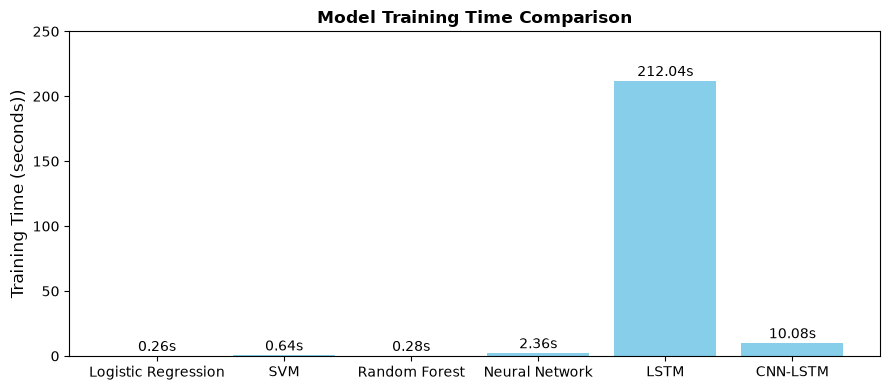

In [52]:
plt.figure(figsize=(9, 4))
bars = plt.bar(training_time.keys(), training_time.values(), color='skyblue')
plt.title("Model Training Time Comparison", fontweight="bold")
plt.ylabel("Training Time (seconds))", fontsize=12)
plt.ylim(0, 250)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, height + 1, f'{round(height,2)}s', ha='center', va='bottom')

plt.tight_layout()
plt.savefig(PLOTS_DIR / "model_training_time_comparison.png", dpi=300)
plt.show()